# **Extended Data Figure 1**
Reproduces panels **a**–**d** of Extended Data Figure 1 from simulation data. Data used:
- `DN_Screen/hyak/run_id=32818869` (**a–b**) 
- `DN_Screen/hyak/run_id=33160051` (**a–b**) 
- `DN_Screen/hyak/run_id=33165976` (**a–b**) 
- `DN_Screen/hyak/run_id=33165981` (**a–b**) 
- `DN_Screen/hyak/run_id=33171362` (**a–b**) 
- `DN_Screen/hyak/run_id=33171365` (**a–b**) 
- `DN_Screen/hyak/run_id=33171374` (**a–b**) 
- `DN_Screen/hyak/run_id=33171377` (**a–b**) 
- `DN_Screen/hyak/run_id=32818378` (**c**)
- `DN_Screen/hyak/run_id=32818869` (**d**)

In [ ]:
dataPath = "/data/users/smpuglie/published-simulations/"

In [ ]:
import matplotlib.pyplot as plt
from src.utils.plot_utils import *
from src.utils.sim_utils import *
import yaml
import numpy as np
import jax.numpy as jnp
import sparse
from hydra import initialize, compose
from hydra.core.hydra_config import HydraConfig
from omegaconf import DictConfig, OmegaConf
from pathlib import Path, PosixPath
import h5py

# # PLOT defaults
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["axes.spines.right"] = "False"
plt.rcParams["axes.spines.top"] = "False"
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["figure.figsize"] = (2,2)
plt.rcParams['axes.linewidth'] = 0.25
plt.rcParams["xtick.major.size"] = 1.7
plt.rcParams["xtick.minor.size"] = 1.0
plt.rcParams["ytick.major.size"] = 1.7
plt.rcParams["ytick.minor.size"] = 1.0
plt.rcParams["xtick.major.width"] = 0.25
plt.rcParams["xtick.minor.width"] = 0.18
plt.rcParams["ytick.major.width"] = 0.25
plt.rcParams["ytick.minor.width"] = 0.18

plt.rcParams["figure.dpi"] = 200

plt.rcParams["axes.labelpad"] = 1.5
plt.rcParams["xtick.major.pad"] = 1.5
plt.rcParams["ytick.major.pad"] = 1.5

SMALL_SIZE = 6
LABEL_SIZE = 7
AXLABEL_SIZE = 8
TITLE_SIZE = 10

plt.rcParams["font.family"] = "Arial" # "Arial"
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=TITLE_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=AXLABEL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=LABEL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=TITLE_SIZE)  # fontsize of the figure title

moduleColors = get_module_colors()

dnColor = "#51bbad"
excColor = "#d84a2e"
inhColor = "#026b85"
mnColor = "#267655"

lightDnColor = "#a7dcd5ff"
lightExcColor = "#ff9985"

Using diffeqsolve-based neural simulation (original)


# standard DN screen (128 replicates)

In [4]:
simType = "DN_Screen"
simPath = simType+"/hyak/run_id=33160051"
folder = dataPath + simPath

params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))
wTable = pd.read_csv("../"+params.experiment["dfPath"].split("vnc-connectome-sim")[1],index_col=0)
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
neuronParams = h5py.File(folder+"/ckpt/neuron_params.h5","r")

inputs = neuronParams["input_currents"][:]
nDns = inputs.shape[0]
nReps = inputs.shape[1]

run_ids = ["32818869","33160051","33165976","33165981","33171362","33171365","33171374","33171377"]

for run_id in run_ids:
    simPath = simType+f"/hyak/run_id={run_id}"
    figFolder = "../figures/"
    figFolder += "-".join(str.split(simPath,"/"))

    scores = pd.read_csv(figFolder+"/scoreSummary.csv",index_col=0)
    nActive = pd.read_csv(figFolder+"/activitySummary.csv",index_col=0)

    if run_id == run_ids[0]:
        combinedScores = scores.copy()
        combinedNActive = nActive.copy()
        dnIdxList = []
        for i in range(len(scores)):
            dnIdxList += np.where(inputs[i].sum(0)>0)[0].tolist()
    else:
        combinedScores = pd.concat([combinedScores,scores],axis=1,ignore_index=True)
        combinedNActive = pd.concat([combinedNActive,nActive],axis=1,ignore_index=True)

/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


In [5]:
figFolder = "../figures/DN_Screen-hyak-combined128reps"

In [6]:
usableScores = combinedScores.copy()
usableScores[combinedNActive<5]=np.nan
usableScores[combinedNActive>1500]=np.nan
usableScoreSummary = pd.DataFrame(usableScores,index=dnIdxList)

## median and IQR

In [7]:
usableScoreSummary["median"] = usableScoreSummary.loc[:,np.arange(128)].quantile(0.5,axis=1)
usableScoreSummary["top5pct"] = usableScoreSummary.loc[:,np.arange(128)].quantile(0.95,axis=1)

tmpToPlot = usableScoreSummary.loc[usableScoreSummary["top5pct"]>0].copy()
tmpToPlot.index = tmpToPlot.index.astype(str)
tmpToPlot = tmpToPlot.sort_values(["median","top5pct"],ascending=False).loc[:,np.arange(128)].transpose()

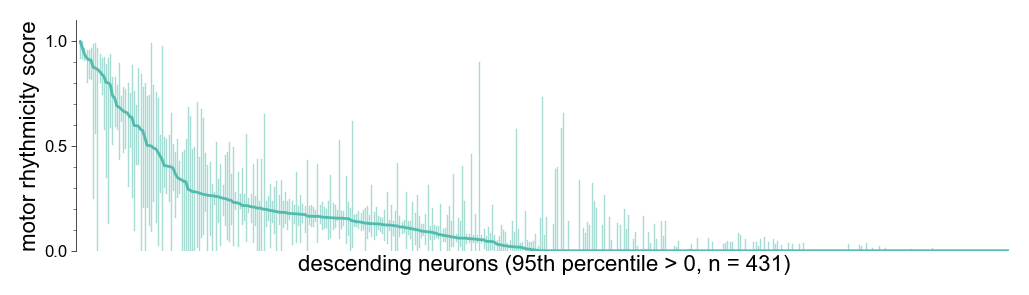

In [8]:
plt.figure(figsize=(6,1.5))

plt.axhline(0,color="k",linestyle="--",linewidth=0.2)

ax = sns.pointplot(tmpToPlot,estimator="median",errorbar=("pi",50),err_kws={"linewidth":0.5,"alpha":0.5},linewidth=1.0,markersize=0.0,color="#51bbad")
plt.xlabel(f"descending neurons (95th percentile > 0, n = {len(tmpToPlot.transpose())})")
plt.ylabel("motor rhythmicity score")
plt.xticks([])

ax.set_ylim([0,1.1])
ax.set_yticks(np.arange(0,1.1,0.5))
ax.set_yticks(np.arange(0,1.1,0.1),minor=True)

sns.despine(offset=1,ax=ax,bottom=True)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/dnScoresMedianLine_wIQR_2.svg",transparent=True)
plt.show()

## best replicates

In [9]:
usableScoreSummary["best"] = usableScoreSummary.iloc[:,1:].max(1,skipna=True)

In [10]:
sum(usableScoreSummary["best"]>=0.5)

233

In [11]:
sum(usableScoreSummary["best"]>=0.5)/sum(usableScoreSummary["best"].notna()) * 100

27.124563445867288

In [12]:
sum(usableScoreSummary["best"]<=0.025)

339

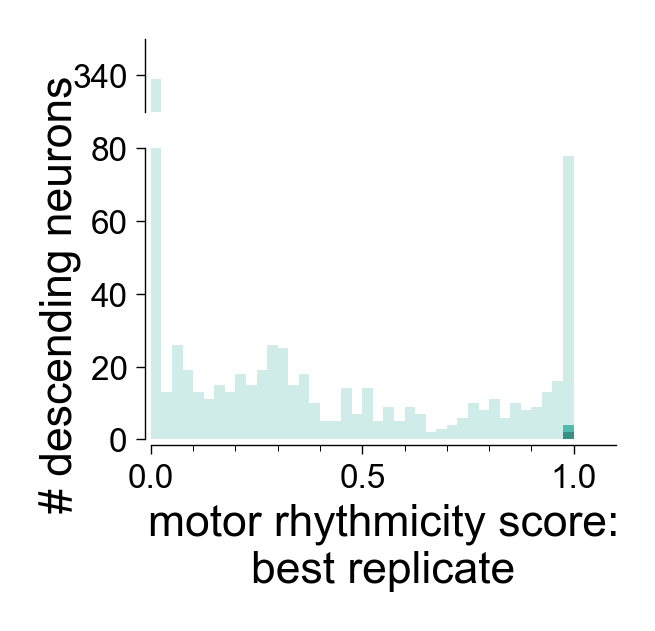

In [13]:
fig,ax = plt.subplots(2,1,height_ratios=[1,4])#,sharex=True)

sns.histplot(usableScoreSummary["best"].dropna(),bins=np.arange(0,1.1,0.02500001),color="#d0ece8ff",edgecolor="None",ax=ax[1],alpha=1,zorder=-1)
sns.histplot(usableScoreSummary.loc[usableScoreSummary.index.isin(wTable.loc[wTable["type"]=="DNb08"].index),"best"],
             bins=np.arange(0,1.1,0.02500001),color="#51bbad",edgecolor="None",ax=ax[1],alpha=1,zorder=1)
sns.histplot(usableScoreSummary.loc[usableScoreSummary.index.isin(wTable.loc[wTable["type"]=="DNg100"].index),"best"],
             bins=np.arange(0,1.1,0.02500001),color="#388f84ff",edgecolor="None",ax=ax[1],alpha=1,zorder=1)
ax[1].set_ylabel("# descending neurons")
# ax[1].yaxis.set_label_position("top")
ax[1].set_xlabel("motor rhythmicity score:\nbest replicate")
ax[1].set_yticks(np.arange(0,1000,20))
ax[1].set_xticks(np.arange(0,1.1,0.5))
ax[1].set_xticks(np.arange(0,1.1,0.1),minor=True)
ax[1].set_xlim([0,1.1])
ax[1].set_ylim([0,80])
# ax[1].invert_xaxis()

sns.histplot(usableScoreSummary["best"].dropna(),bins=np.arange(0,1.1,0.02500001),color="#d0ece8ff",edgecolor="None",ax=ax[0],alpha=1)
# ax[0].invert_xaxis()
ax[0].set_ylabel("")
ax[0].set_yticks(np.arange(0,1000,20))
ax[0].set_ylim([330,350])
ax[0].set_xlim([0,1.1])
ax[0].set_xticks([])
ax[0].set_xlabel("")

sns.despine(offset=1,ax=ax[1])#,top=False,bottom=True)
sns.despine(offset=1,ax=ax[0],bottom=True)#,top=False,bottom=True,left=True)

fig.set_dpi(400)

fig.set_figheight(1.3)
fig.set_figwidth(1.5)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/dnBestScoresHist_vertical2.svg",transparent=True)
plt.show()

# DN screen by type

In [15]:
simType = "DN_Screen"
simPath = simType+"/hyak/run_id=32818378"
folder = dataPath + simPath

params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))
wTable = pd.read_csv("../"+params.experiment["dfPath"].split("vnc-connectome-sim")[1],index_col=0)
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
neuronParams = h5py.File(folder+"/ckpt/neuron_params.h5","r")

# ckptH5 = ioh5.load(folder+"/ckpt/checkpoints/results_checkpoint_batch_58/checkpoint_batch_58.h5")
# ckptNeuronParams = ckptH5["neuron_params"]
# ckptInputs = ["input_currents"][:]
inputs = neuronParams["input_currents"][:]
nDns = inputs.shape[0]
nReps = inputs.shape[1]

/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


## load data

### run the first time to load all outputs and save the summary

In [16]:
# scores = np.zeros((nDns,nReps))
# nActive = np.zeros((nDns,nReps))
# # nMnsActive = np.zeros((nDns,nReps))
# dnTypeList = []

# finalResultsDir = folder + "/ckpt/checkpoints/results_final"
# Rs_batch = sparse.load_npz(finalResultsDir+f"/Final_batch_Rs_0.npz").todense()
# # print(f"Loaded batch 0, shape {Rs_batch.shape}.")
# batchSize = len(Rs_batch)

# for batch in tqdm(range(len(os.listdir(finalResultsDir)))):
    
#     if batch !=0:
#         Rs_batch = sparse.load_npz(finalResultsDir+f"/Final_batch_Rs_{batch}.npz").todense()
#     print(f"Loaded batch {batch}, shape {Rs_batch.shape}.")
    
#     for i in range(len(Rs_batch)):
#         global_i = batch*batchSize + i
#         nrnNo = global_i // nReps
#         rep = global_i % nReps
        
#         dnType = wTable.loc[np.where(inputs[nrnNo].sum(0)>0)[0],"type"].unique()
#         if len(dnType)>1:
#             raise ValueError("error: each stim should only be one type")
#         if dnType not in dnTypeList:
#             dnTypeList += dnType.tolist()

#         R = Rs_batch[i]
#         activeMask = np.max(R,1)>0.01
#         nActive[nrnNo,rep] = np.sum(activeMask)
#         # activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
#         # nMnsActive[nrnNo,rep] = np.sum(activeMnsMask)
#         activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
#         score, _ = compute_oscillation_score(R[...,250:],activeMnsMaskPastTransient)
#         scores[nrnNo,rep] = score

In [17]:
# scoreSummary = pd.DataFrame(scores,index=dnTypeList)
# activitySummary = pd.DataFrame(nActive,index=dnTypeList)

# figFolder = "../figures/"
# figFolder += "-".join(str.split(simPath,"/"))

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# scoreSummary.to_csv(figFolder+"/scoreSummary.csv")
# activitySummary.to_csv(figFolder+"/activitySummary.csv")

### run if the summary is already created to load it

In [18]:
figFolder = "../figures/"
figFolder += "-".join(str.split(simPath,"/"))

scores = pd.read_csv(figFolder+"/scoreSummary.csv",index_col=0)
nActive = pd.read_csv(figFolder+"/activitySummary.csv",index_col=0)

dnTypeList = []
for i in range(len(scores)):
    dnTypeList += wTable.loc[np.where(inputs[i].sum(0)>0)[0],"type"].unique().tolist()

## quantify and plot results

In [19]:
usableScores = scores.copy()
usableScores[nActive<5]=np.nan
usableScores[nActive>1500]=np.nan
usableScoreSummary = pd.DataFrame(usableScores,index=dnTypeList)
usableScoreSummary

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
DNp01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
DNp18,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
DNxl053,0.530238,0.000000,0.655687,0.532959,0.700489,0.000000,0.614824,0.626419,0.411182,0.752190,0.000000,0.682421,0.684388,0.512818,0.610827,0.000000
DNg100,0.996042,0.874544,0.730637,0.945262,0.948641,0.768156,0.929462,0.968423,0.871271,0.998154,0.984984,0.995411,0.844936,0.900885,0.802955,0.774181
DNg15,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.798243,0.000000,0.000000,0.851641,0.000000,0.000000,0.172978,0.000000,0.540242,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DNit011,0.822018,0.733553,0.918902,0.983384,0.548851,0.779179,0.972909,0.035260,0.850317,0.917273,0.882647,0.831260,0.832816,0.553889,0.839220,0.701008
DNxn104,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
DNit003,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
DNfl043,0.285913,0.359050,0.000000,0.152807,0.070725,0.383705,0.476262,0.090919,0.000000,0.369465,0.040370,0.215935,0.058478,0.139535,0.338435,0.198501


In [20]:
len(usableScores)

321

In [21]:
usableScoreSummary.notna().sum(1).value_counts().sort_index()

0       5
2       2
4       2
5       1
6       2
7       1
8       1
9       4
10      4
12      2
14      3
15      1
16    293
Name: count, dtype: int64

In [22]:
usableScoreSummary["mean"] = usableScoreSummary.mean(1,skipna=True)
usableScoreSummary.insert(0,"bodyId",usableScoreSummary.index.map(dict(zip(wTable.index,wTable["bodyId"]))))

In [23]:
sum(usableScoreSummary["mean"].notna())

316

In [24]:
sum(usableScoreSummary["mean"].isna())

5

In [25]:
sum(usableScoreSummary["mean"]==0)

129

In [26]:
sum(usableScoreSummary["mean"]>=0.5)

11

In [27]:
sum(usableScoreSummary["mean"]>=0.5)/sum(usableScoreSummary["mean"].notna()) * 100

3.481012658227848

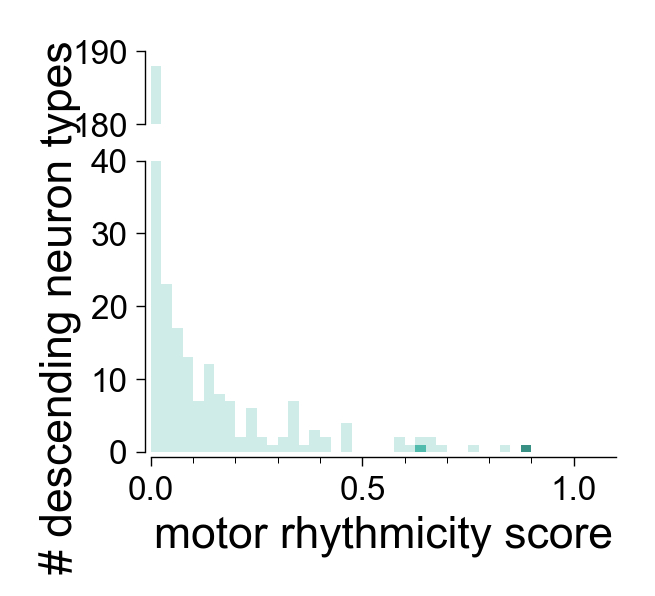

In [28]:
fig,ax = plt.subplots(2,1,height_ratios=[1,4])#,sharex=True)

sns.histplot(usableScoreSummary["mean"].dropna(),bins=np.arange(0,1.1,0.025),color="#d0ece8ff",edgecolor="None",ax=ax[1],alpha=1,zorder=-1)
sns.histplot(usableScoreSummary.loc[usableScoreSummary.index == "DNb08","mean"],
             bins=np.arange(0,1.1,0.025),color="#51bbad",edgecolor="None",ax=ax[1],alpha=1,zorder=1)
sns.histplot(usableScoreSummary.loc[usableScoreSummary.index == "DNg100","mean"],
             bins=np.arange(0,1.1,0.025),color="#388f84ff",edgecolor="None",ax=ax[1],alpha=1,zorder=1)
ax[1].set_ylabel("# descending neuron types")
# ax[1].yaxis.set_label_position("top")
ax[1].set_xlabel("motor rhythmicity score")
ax[1].set_yticks(np.arange(0,1000,10))
ax[1].set_xticks(np.arange(0,1.1,0.5))
ax[1].set_xticks(np.arange(0,1.1,0.1),minor=True)
ax[1].set_xlim([0,1.1])
ax[1].set_ylim([0,40])
# ax[1].invert_xaxis()

sns.histplot(usableScoreSummary["mean"].dropna(),bins=np.arange(0,1.1,0.025),color="#d0ece8ff",edgecolor="None",ax=ax[0],alpha=1)
# ax[0].invert_xaxis()
ax[0].set_ylabel("")
ax[0].set_yticks(np.arange(0,1000,10))
ax[0].set_ylim([180,190])
ax[0].set_xlim([0,1.1])
ax[0].set_xticks([])
ax[0].set_xlabel("")

sns.despine(offset=1,ax=ax[1])#,top=False,bottom=True)
sns.despine(offset=1,ax=ax[0],bottom=True)#,top=False,bottom=True,left=True)
# ax[1].yaxis.tick_top()
# ax[0].yaxis.tick_top()

fig.set_dpi(400)

fig.set_figheight(1.3)
fig.set_figwidth(1.5)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/dnTypesScoresHist_vertical.svg",transparent=True)
plt.show()

In [29]:
pd.DataFrame(usableScoreSummary["mean"].sort_values(ascending=False).iloc[:sum(usableScoreSummary["mean"]>=0.5)])

,mean
DNg100,0.895871
DNa07,0.842740
DNit011,0.762655
DNit013,0.693054
DNxl102,0.656628
DNp41,0.651774
DNxl101,0.633791
DNb08,0.627601
DNxl133,0.622664
DNg54,0.589330


# DN screen with E1s silenced

In [31]:
simType = "DN_Screen"
simPath = simType+"/hyak/run_id=32818869" 
folder = dataPath + simPath

params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))
wTable = pd.read_csv("../"+params.experiment["dfPath"].split("vnc-connectome-sim")[1],index_col=0)
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
neuronParams = h5py.File(folder+"/ckpt/neuron_params.h5","r")

inputs = neuronParams["input_currents"][:]
nDns = inputs.shape[0]
nReps = inputs.shape[1]

/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


## load data

### run the first time to load all outputs and save the summary

In [32]:
# scores = np.zeros((nDns,nReps))
# nActive = np.zeros((nDns,nReps))
# # nMnsActive = np.zeros((nDns,nReps))
# dnTypeList = []

# finalResultsDir = folder + "/ckpt/checkpoints/results_final"
# Rs_batch = sparse.load_npz(finalResultsDir+f"/Final_batch_Rs_0.npz").todense()
# # print(f"Loaded batch 0, shape {Rs_batch.shape}.")
# batchSize = len(Rs_batch)

# for batch in tqdm(range(len(os.listdir(finalResultsDir)))):
    
#     if batch !=0:
#         Rs_batch = sparse.load_npz(finalResultsDir+f"/Final_batch_Rs_{batch}.npz").todense()
#     print(f"Loaded batch {batch}, shape {Rs_batch.shape}.")
    
#     for i in range(len(Rs_batch)):
#         global_i = batch*batchSize + i
#         nrnNo = global_i // nReps
#         rep = global_i % nReps
        
#         dnType = wTable.loc[np.where(inputs[nrnNo].sum(0)>0)[0],"type"].unique()
#         if len(dnType)>1:
#             raise ValueError("error: each stim should only be one type")
#         if dnType not in dnTypeList:
#             dnTypeList += dnType.tolist()

#         R = Rs_batch[i]
#         activeMask = np.max(R,1)>0.01
#         nActive[nrnNo,rep] = np.sum(activeMask)
#         # activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
#         # nMnsActive[nrnNo,rep] = np.sum(activeMnsMask)
#         activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
#         score, _ = compute_oscillation_score(R[...,250:],activeMnsMaskPastTransient)
#         scores[nrnNo,rep] = score

In [33]:
# scoreSummary = pd.DataFrame(scores,index=dnTypeList)
# activitySummary = pd.DataFrame(nActive,index=dnTypeList)

# figFolder = "../figures/"
# figFolder += "-".join(str.split(simPath,"/"))

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# scoreSummary.to_csv(figFolder+"/scoreSummary.csv")
# activitySummary.to_csv(figFolder+"/activitySummary.csv")

### run if the summary is already created to load it

In [34]:
figFolder = "../figures/"
figFolder += "-".join(str.split(simPath,"/"))

scores = pd.read_csv(figFolder+"/scoreSummary.csv",index_col=0)
nActive = pd.read_csv(figFolder+"/activitySummary.csv",index_col=0)

dnTypeList = []
for i in range(len(scores)):
    dnTypeList += wTable.loc[np.where(inputs[i].sum(0)>0)[0],"type"].unique().tolist()

## plot results

In [35]:
usableScores = scores.copy()
usableScores[nActive<5]=np.nan
usableScores[nActive>1500]=np.nan
usableScoreSummary = pd.DataFrame(usableScores,index=dnIdxList)

usableScoreSummary["mean"] = usableScoreSummary.mean(1,skipna=True)
usableScoreSummary.insert(0,"bodyId",usableScoreSummary.index.map(dict(zip(wTable.index,wTable["bodyId"]))))
usableScoreSummary.sort_values("mean",ascending=False)

,bodyId,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,mean
1745,16683,0.956500,0.993497,0.993232,0.962954,0.962051,0.977471,0.908636,0.998007,0.856238,0.609827,0.995039,0.831034,0.928154,0.118518,0.991712,0.991710,0.879661
2026,18153,0.937170,0.932066,0.914048,0.946179,0.979184,0.955422,0.894015,0.956397,0.945837,0.952365,0.960570,0.925038,0.947956,0.906800,0.000000,0.907462,0.878782
2048,18279,0.961182,0.987897,0.964758,0.875952,0.878333,0.859932,0.895499,0.924624,0.971566,0.975959,0.140971,0.656633,0.900798,0.933433,0.875880,0.976023,0.861215
4002,44321,0.920169,0.916868,0.981492,0.856569,0.805782,0.344368,0.924164,0.533686,0.720954,0.798310,0.959531,0.678739,0.942714,0.979062,0.972189,0.801339,0.820996
2860,23461,0.933805,0.000000,0.998516,0.947905,0.793793,0.993225,0.865280,0.997223,0.005995,0.996252,0.785688,0.985638,0.486030,0.992938,0.997822,0.976052,0.797260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4231,102117,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4267,104140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4480,163893,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4512,166522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


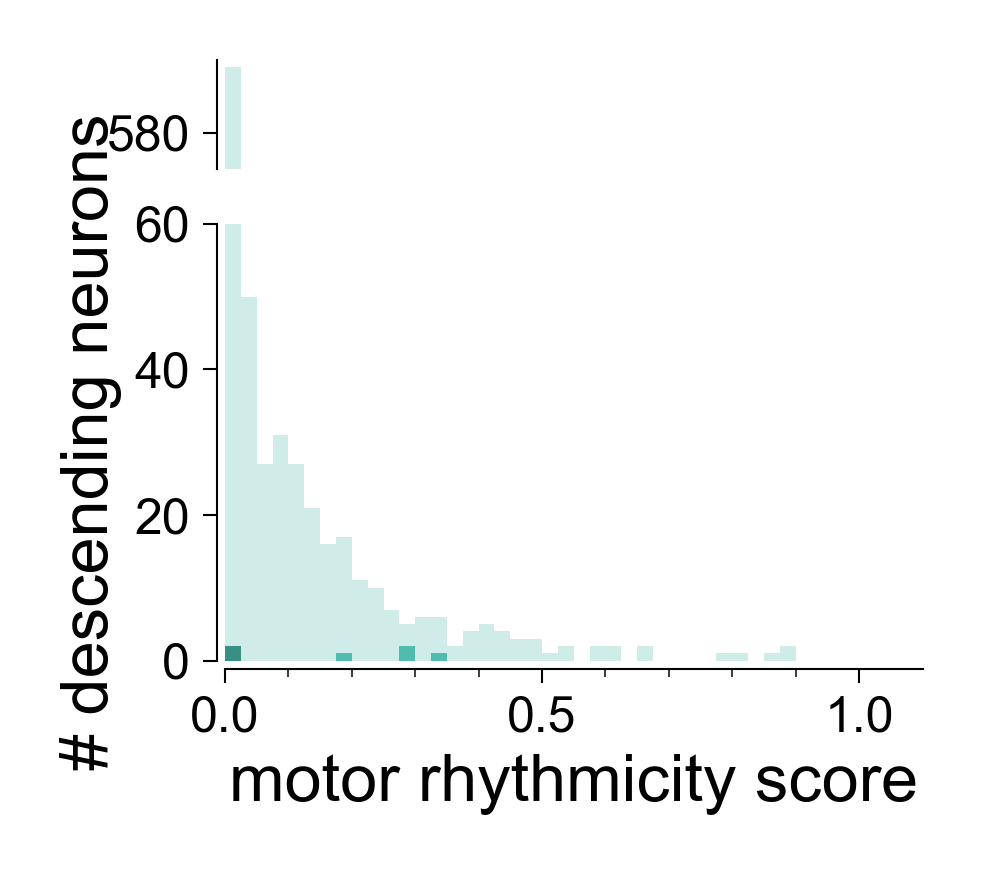

In [36]:
fig,ax = plt.subplots(2,1,height_ratios=[1,4])#,sharex=True)

sns.histplot(usableScoreSummary["mean"].dropna(),bins=np.arange(0,1.1,0.025),color="#d0ece8ff",edgecolor="None",ax=ax[1],alpha=1,zorder=-1)
sns.histplot(usableScoreSummary.loc[usableScoreSummary.index.isin(wTable.loc[wTable["type"]=="DNb08"].index),"mean"],
             bins=np.arange(0,1.1,0.025),color="#51bbad",edgecolor="None",ax=ax[1],alpha=1,zorder=1)
sns.histplot(usableScoreSummary.loc[usableScoreSummary.index.isin(wTable.loc[wTable["type"]=="DNg100"].index),"mean"],
             bins=np.arange(0,1.1,0.025),color="#388f84ff",edgecolor="None",ax=ax[1],alpha=1,zorder=1)
ax[1].set_ylabel("# descending neurons")
# ax[1].yaxis.set_label_position("top")
ax[1].set_xlabel("motor rhythmicity score")
ax[1].set_yticks(np.arange(0,1000,20))
ax[1].set_xticks(np.arange(0,1.1,0.5))
ax[1].set_xticks(np.arange(0,1.1,0.1),minor=True)
ax[1].set_xlim([0,1.1])
ax[1].set_ylim([0,60])
# ax[1].invert_xaxis()

sns.histplot(usableScoreSummary["mean"].dropna(),bins=np.arange(0,1.1,0.025),color="#d0ece8ff",edgecolor="None",ax=ax[0],alpha=1)
# ax[0].invert_xaxis()
ax[0].set_ylabel("")
ax[0].set_yticks(np.arange(0,1000,20))
ax[0].set_ylim([575,590])
ax[0].set_xlim([0,1.1])
ax[0].set_xticks([])
ax[0].set_xlabel("")

sns.despine(offset=1,ax=ax[1])#,top=False,bottom=True)
sns.despine(offset=1,ax=ax[0],bottom=True)#,top=False,bottom=True,left=True)
# ax[1].yaxis.tick_top()
# ax[0].yaxis.tick_top()

fig.set_dpi(600)

fig.set_figheight(1.3)
fig.set_figwidth(1.5)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/dnScoresHist_vertical.svg",transparent=True)
plt.show()

## compare to intact 128x screen

In [37]:
simType = "DN_Screen"
simPath = simType+"/hyak/run_id=33160051"
folder = dataPath + simPath

params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))
wTable = pd.read_csv("../"+params.experiment["dfPath"].split("vnc-connectome-sim")[1],index_col=0)
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
neuronParams = h5py.File(folder+"/ckpt/neuron_params.h5","r")

inputs = neuronParams["input_currents"][:]
nDns = inputs.shape[0]
nReps = inputs.shape[1]

run_ids = ["32818869","33160051","33165976","33165981","33171362","33171365","33171374","33171377"]

for run_id in run_ids:
    simPath = simType+f"/hyak/run_id={run_id}"
    figFolder = "../figures/"
    figFolder += "-".join(str.split(simPath,"/"))

    scores = pd.read_csv(figFolder+"/scoreSummary.csv",index_col=0)
    nActive = pd.read_csv(figFolder+"/activitySummary.csv",index_col=0)

    if run_id == run_ids[0]:
        combinedScores = scores.copy()
        combinedNActive = nActive.copy()
        dnIdxList = []
        for i in range(len(scores)):
            dnIdxList += np.where(inputs[i].sum(0)>0)[0].tolist()
    else:
        combinedScores = pd.concat([combinedScores,scores],axis=1,ignore_index=True)
        combinedNActive = pd.concat([combinedNActive,nActive],axis=1,ignore_index=True)

usableIntactScores = combinedScores.copy()
usableIntactScores[combinedNActive<5]=np.nan
usableIntactScores[combinedNActive>1500]=np.nan
intactScoreSummary = pd.DataFrame(usableIntactScores,index=dnIdxList)

intactScoreSummary["mean"] = intactScoreSummary.mean(1,skipna=True)
intactScoreSummary.insert(0,"bodyId",intactScoreSummary.index.map(dict(zip(wTable.index,wTable["bodyId"]))))
intactScoreSummary.sort_values("mean",ascending=False)

/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


,bodyId,0,1,2,3,4,5,6,7,8,...,119,120,121,122,123,124,125,126,127,mean
2026,18153,0.93717,0.932066,0.914048,0.946179,0.979184,0.955422,0.894015,0.956397,0.945837,...,0.000000,0.820966,0.987958,0.941971,0.991807,0.992486,0.899656,0.985851,0.954624,0.921685
1745,16683,0.95650,0.993497,0.993232,0.962954,0.962051,0.977471,0.908636,0.998007,0.856238,...,0.891749,0.974294,0.808930,0.746899,0.955815,0.808724,0.959869,0.923574,0.804239,0.854303
31,10093,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.950259,0.997931,0.995438,0.998826,0.959194,0.907840,0.994494,1.000000,0.994676,0.850086
132,10339,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.909782,0.914197,1.000000,0.901276,0.950359,0.991408,0.931881,0.996419,0.997456,0.836744
3602,30919,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.889877,0.892219,0.902799,0.876108,0.783699,0.935978,0.914479,0.956032,0.991830,0.793973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4086,53062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4231,102117,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4480,163893,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4512,166522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
topIntactScorers = intactScoreSummary[["bodyId","mean"]].sort_values("mean",ascending=False).iloc[:29]
topIntactScorers["mean_e1silenced"] = usableScoreSummary.loc[topIntactScorers.index,"mean"]
topIntactScorers.insert(1,"type",topIntactScorers.index.map(dict(zip(wTable.index,wTable["type"]))))
topIntactScorers

,bodyId,type,mean,mean_e1silenced
2026,18153,DNp41,0.921685,0.878782
1745,16683,DNxl091,0.854303,0.879661
31,10093,DNg100,0.850086,0.000000
132,10339,DNg100,0.836744,0.000000
3602,30919,DNg12,0.793973,0.000000
2048,18279,DNp41,0.791299,0.861215
4002,44321,DNit011,0.777426,0.820996
3711,32815,DNg12,0.739332,0.000000
2860,23461,DNfl031,0.730864,0.797260
1211,14061,DNb08,0.727479,0.338371


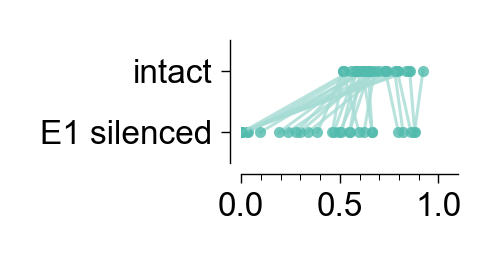

In [39]:
fig = plt.figure(figsize=(0.7,0.4))
for i in topIntactScorers.index:
    plt.plot([topIntactScorers.loc[i,"mean_e1silenced"],topIntactScorers.loc[i,"mean"]], ['E1 silenced', 'intact'], 
             marker='o',color=lightDnColor,alpha=0.8,markersize=2,markerfacecolor=dnColor,markeredgecolor="none",linewidth=0.55)
    
plt.xlim([0,1.1])
plt.xticks(np.arange(0,1.1,0.5))
plt.xticks(np.arange(0,1.1,0.1),minor=True)
plt.ylim([-0.5,1.5])

fig.set_dpi(400)
sns.despine(offset = 2)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/dnScores_pairedDecrease.svg",transparent=True)
plt.show()

In [ ]:
topIntactScorers["difference"] = topIntactScorers["mean_e1silenced"] - topIntactScorers["mean"]
topIntactScorers.sort_values("difference")

,bodyId,type,mean,mean_e1silenced,difference
31,10093,DNg100,0.850086,0.000000,-0.850086
132,10339,DNg100,0.836744,0.000000,-0.836744
3602,30919,DNg12,0.793973,0.000000,-0.793973
3711,32815,DNg12,0.739332,0.000000,-0.739332
3161,25931,DNa07,0.638171,0.034893,-0.603278
3706,32742,DNg12,0.558370,0.004666,-0.553705
2921,23962,DNxn127,0.584200,0.032243,-0.551956
3559,30130,DNxn167,0.620578,0.097103,-0.523474
2302,19821,DNg54,0.697184,0.235524,-0.461659
1164,13892,DNb08,0.618388,0.192396,-0.425991


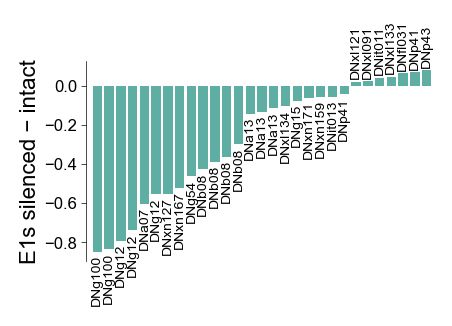

In [42]:
tmp = topIntactScorers.sort_values("difference")
tmp["bodyId"] = tmp["bodyId"].astype(str)

ax = sns.barplot(tmp,x="bodyId",y="difference",color=dnColor)
ax.bar_label(ax.containers[0], fontsize=5, labels=tmp["type"],rotation=90,padding=1)

# ax.bar_label(ax.containers[0], fontsize=5, labels=[f'{tmp.loc[i,"type"]} ({tmp.loc[i,"bodyId"]})' for i in tmp.index],rotation=90,padding=1)
plt.xticks([])
plt.xlabel("")
sns.despine(offset=2,bottom=True)
plt.ylabel("E1s silenced − intact")

fig = plt.gcf()
fig.set_figheight(1.3)
fig.set_figwidth(2.2)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/dnScores_barDecrease.svg",transparent=True)
plt.show()